<a href="https://colab.research.google.com/github/pattichis/MLSP2026/blob/main/BiomedGPT_HF_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### use the pre-trained biomedgpt from huggingface -- PanaceaAI/BiomedGPT-Base-Pretrained

In [ ]:
# download the same-size pretrained HF variant of the finetuned variant that you want to convert from.
model_name = "BiomedGPT-Base-Pretrained"
!git clone https://huggingface.co/PanaceaAI/{model_name}

Cloning into 'BiomedGPT-Base-Pretrained'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 9 (from 1)
Receiving objects: 100% (10/10), 536.88 KiB | 19.17 MiB/s, done.


In [ ]:
!git clone --single-branch --branch feature/add_transformers https://github.com/OFA-Sys/OFA.git

!pip install OFA/transformers

Cloning into 'OFA'...
remote: Enumerating objects: 5745, done.
remote: Counting objects: 100% (932/932), done.
remote: Compressing objects: 100% (256/256), done.
remote: Total 5745 (delta 710), reused 676 (delta 676), pack-reused 4813 (from 1)
Receiving objects: 100% (5745/5745), 97.78 MiB | 14.57 MiB/s, done.
Resolving deltas: 100% (2243/2243), done.
Updating files: 100% (3223/3223), done.
Processing ./OFA/transformers
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.8/867.8 kB 26.1 MB/s eta 0:00:00
  Created wheel for transformers: filename=transformers-4.18.0.dev0-py3-none-any.whl size=3916872 sha256=e2bcdb321be765e3ad3f1233c5eaee36981a3acd9da903d1892d62db29319918
  Stored in directory: /tmp/pip-ephem-wheel-cache-haw6baiw/wheels/e5/f5/74/2ce21b995914eb8d4d7a7a7db29a928cc4

In [ ]:
import os

# Install git-lfs (if not already installed)
!apt-get update && apt-get install -y git-lfs

# Initialize git lfs
!git lfs install

# Change to the model directory to pull the LFS files
original_cwd = os.getcwd()
os.chdir(model_name)
!git lfs pull

# Change back to the original directory
os.chdir(original_cwd)

from transformers import OFATokenizer, OFAModel
tokenizer = OFATokenizer.from_pretrained(f"./{model_name}")
model = OFAModel.from_pretrained(f"./{model_name}")

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:3 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Hit:5 http://archive.ubuntu.com/ubuntu noble InRelease
Get:6 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease [17.8 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [73.2 kB]
Get:9 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.2 MB]
Get:11 https://r2u.stat.illinois.edu/ubuntu noble/main amd64 Packages [3,020 kB]
Get:12 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [1,905 kB]
Get:13 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble/main amd64 Pack

/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [ ]:
import re

import torch
from PIL import Image
from torchvision import transforms


mean, std = [0.5, 0.5, 0.5], [0.5, 0.5, 0.5]
resolution = 480

patch_resize_transform = transforms.Compose([
        lambda image: image.convert("RGB"),
        transforms.Resize((resolution, resolution), interpolation=Image.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])


In [ ]:
!gdown --id 1kojeqtJSx3MzdY3jd--XzeJrdyiFuzC8 -O example.jpg

img = Image.open('example.jpg')

txt = "What modality is used to take this image?"
inputs = tokenizer([txt], return_tensors="pt").input_ids
patch_img = patch_resize_transform(img).unsqueeze(0)

gen = model.generate(inputs, patch_images=patch_img, num_beams=5, no_repeat_ngram_size=3, max_length=16)
results = tokenizer.batch_decode(gen, skip_special_tokens=True)

result = results[0]
result = re.sub(r'[^\w\s]', '', result).strip()

result

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1kojeqtJSx3MzdY3jd--XzeJrdyiFuzC8
To: /content/example.jpg
100% 14.6k/14.6k [00:00<00:00, 30.3MB/s]


'MRI'

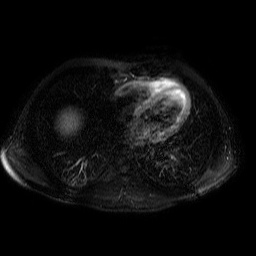

In [ ]:
img

In [ ]:
txt = "What does the image represent?"
inputs = tokenizer([txt], return_tensors="pt").input_ids
patch_img = patch_resize_transform(img).unsqueeze(0)

gen = model.generate(inputs, patch_images=patch_img, num_beams=5, no_repeat_ngram_size=3, max_length=16)
results = tokenizer.batch_decode(gen, skip_special_tokens=True)

result = results[0]
result = re.sub(r'[^\w\s]', '', result).strip()

result

'coexistence of fibrinopurulent exudate'